# Heat Equation PINN - Version 1 (Standard)

This notebook implements a standard Physics-Informed Neural Network (PINN) to solve the 1D heat equation. The PDE residual loss is computed strictly using the first-order time derivative and the second-order spatial derivative:
$$\text{Loss}_{CLP} = \text{mean}((u_t - \alpha u_{xx})^2)$$

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

## 1. PINN Architecture Definition
Definition of the standard Neural Network (Multi-Layer Perceptron) to approximate the solution $u(t,x)$.

In [2]:
class PinnHeatEq(nn.Module):
    def __init__(self):
        super().__init__()
        self.couche_entree = nn.Linear(2, 50)
        self.couche_cachee1 = nn.Linear(50, 50)
        self.couche_cachee2 = nn.Linear(50, 50)
        self.couche_sortie = nn.Linear(50, 1)

    def forward(self, x):
        x = torch.tanh(self.couche_entree(x))
        x = torch.tanh(self.couche_cachee1(x))
        x = torch.tanh(self.couche_cachee2(x))
        return self.couche_sortie(x)

## 2. Sampling and Collocation Points Generation
Functions to generate collocation points (in the domain), initial points ($t=0$), and boundary points ($x=0$ and $x=1$).

In [3]:
t_min, t_max = 0.0, 1.0
x_min, x_max = 0.0, 1.0


def generer_points_collocation(n_pde):
    t_colloc = torch.rand(n_pde, 1) * (t_max - t_min) + t_min
    x_colloc = torch.rand(n_pde, 1) * (x_max - x_min) + x_min
    return t_colloc.float(), x_colloc.float()


def generer_points_initiaux(n_iv):
    t_init = torch.zeros(n_iv, 1)
    x_init = torch.rand(n_iv, 1) * (x_max - x_min) + x_min
    return t_init.float(), x_init.float()


def generer_points_bords(n_bords):
    t_bord = torch.rand(n_bords, 1) * (t_max - t_min) + t_min
    x_gauche = torch.ones(n_bords // 2, 1) * x_min
    x_droite = torch.ones(n_bords // 2, 1) * x_max
    x_bord = torch.cat([x_gauche, x_droite], dim=0)
    return t_bord.float(), x_bord.float()

## 3. Loss Functions Definition
Grouping of loss calculation functions for initial conditions (IV), boundary conditions (BC), and the PDE residual (CLP).

In [4]:
def calc_iv_loss(model, t_init, x_init, u_exact_init):
    u_pred = model(torch.cat([t_init, x_init], dim=1))
    return torch.mean((u_pred - u_exact_init) ** 2)


def calc_bc_loss(model, t_bord, x_bord, u_exact_bord):
    u_pred = model(torch.cat([t_bord, x_bord], dim=1))
    return torch.mean((u_pred - u_exact_bord) ** 2)


def calc_clp_loss(model, t_colloc, x_colloc, alpha):
    t_colloc.requires_grad_(True)
    x_colloc.requires_grad_(True)

    u_pred = model(torch.cat([t_colloc, x_colloc], dim=1))

    u_t = torch.autograd.grad(
        outputs=u_pred,
        inputs=t_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_x = torch.autograd.grad(
        outputs=u_pred,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
    )[0]

    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
    )[0]

    residu = u_t - alpha * u_xx
    return torch.mean(residu ** 2)

## 4. Hardware (Device), Model, and Optimizer Initialization
Hardware detection, model creation, and optimizer definition.

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

alpha = 0.0005

modele = PinnHeatEq().to(device)
optimizer = optim.Adam(modele.parameters(), lr=0.001)

t_colloc, x_colloc = generer_points_collocation(12000)
t_init, x_init = generer_points_initiaux(1000)
t_bord, x_bord = generer_points_bords(1000)

u_exact_init = torch.sin(2 * torch.pi * x_init)
u_exact_bord = torch.zeros_like(x_bord)

t_colloc, x_colloc = t_colloc.to(device), x_colloc.to(device)
t_init, x_init = t_init.to(device), x_init.to(device)
t_bord, x_bord = t_bord.to(device), x_bord.to(device)
u_exact_init = u_exact_init.to(device)
u_exact_bord = u_exact_bord.to(device)

cuda


## 5. Model Training
Training phase of the PINN model using the defined optimizers (Adam and/or L-BFGS).

In [6]:
epochs = 12000

for epoch in range(epochs):
    optimizer.zero_grad()

    loss_iv = calc_iv_loss(modele, t_init, x_init, u_exact_init)
    loss_bc = calc_bc_loss(modele, t_bord, x_bord, u_exact_bord)
    loss_clp = calc_clp_loss(modele, t_colloc, x_colloc, alpha)

    loss_totale = 300 * loss_iv + 100 * loss_bc + loss_clp
    loss_totale.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoque {epoch:05d} | "
              f"Loss totale: {loss_totale.item():.2e} | "
              f"CLP: {loss_clp.item():.2e} | "
              f"BC: {loss_bc.item():.2e} | "
              f"IV: {loss_iv.item():.2e}")

C:\Users\Chabc\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoque 00000 | Loss totale: 1.56e+02 | CLP: 2.32e-04 | BC: 1.05e-02 | IV: 5.15e-01
Epoque 00100 | Loss totale: 7.32e+01 | CLP: 2.73e-01 | BC: 1.28e-01 | IV: 2.00e-01
Epoque 00200 | Loss totale: 5.73e+00 | CLP: 1.58e+00 | BC: 5.05e-03 | IV: 1.22e-02
Epoque 00300 | Loss totale: 1.69e+00 | CLP: 6.04e-01 | BC: 2.06e-03 | IV: 2.94e-03
Epoque 00400 | Loss totale: 5.05e-01 | CLP: 2.51e-01 | BC: 6.29e-04 | IV: 6.38e-04
Epoque 00500 | Loss totale: 2.32e-01 | CLP: 1.60e-01 | BC: 2.69e-04 | IV: 1.49e-04
Epoque 00600 | Loss totale: 1.59e-01 | CLP: 1.16e-01 | BC: 1.66e-04 | IV: 8.75e-05
Epoque 00700 | Loss totale: 3.97e-01 | CLP: 8.74e-02 | BC: 7.16e-04 | IV: 7.94e-04
Epoque 00800 | Loss totale: 9.98e-02 | CLP: 6.85e-02 | BC: 1.07e-04 | IV: 6.85e-05
Epoque 00900 | Loss totale: 3.23e-01 | CLP: 5.52e-02 | BC: 5.99e-04 | IV: 6.93e-04
Epoque 01000 | Loss totale: 7.20e-02 | CLP: 4.62e-02 | BC: 7.97e-05 | IV: 5.93e-05
Epoque 01100 | Loss totale: 6.19e-02 | CLP: 3.92e-02 | BC: 6.88e-05 | IV: 5.25e-05
Epoq

## 6. Visualizing the Results
Comparison of the solution learned by the PINN with the exact analytical solution of the heat equation.

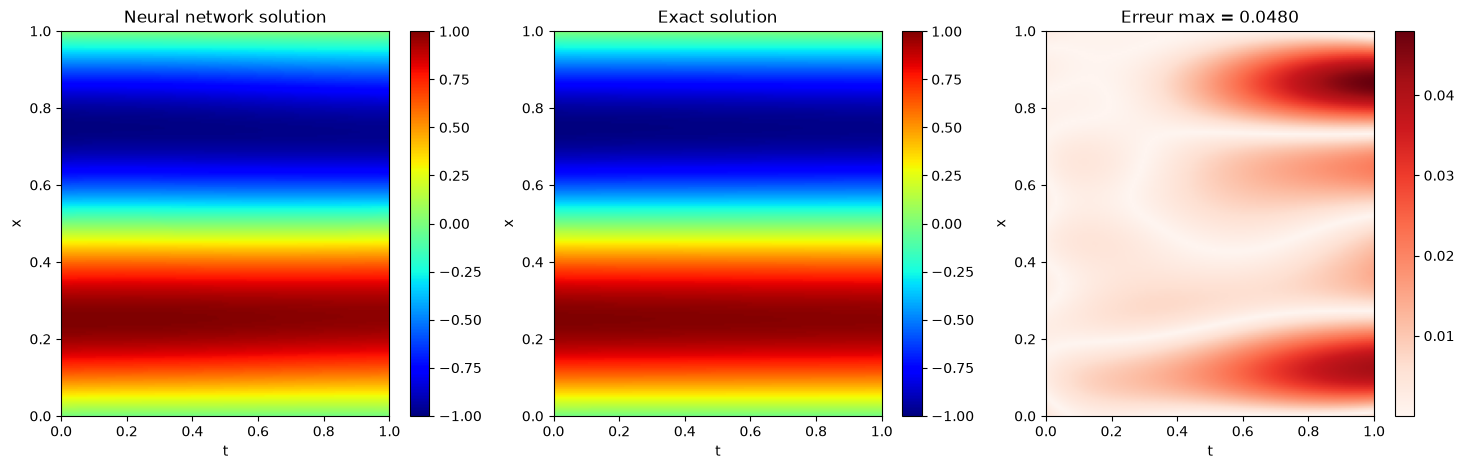

In [7]:
import sys; sys.path.append("..")
import numpy as np                                                                                                    
from pinnplot import plot_solution                        

u_exact = lambda t, x: np.sin(2*np.pi*x) * np.exp(-(2*np.pi)**2 * alpha * t)

plot_solution(modele, u_exact)           


## 7. Ablation / Verification — 75/25 Train–Validation Split

This is a **forward** problem, so there is no observation *data* to split. Instead we split the **collocation points**:
- **75%** used to train the PDE residual (`train`),
- **25%** kept **held-out** to *verify* the residual on **unseen** points (`validation`) — this measures whether the physics **generalizes** or the network **overfits the collocation points**.

Because the exact solution is known here, we also track the **true relative L2 error** vs the analytical solution — the ultimate verification.

This split is the scaffold for a real **ablation study**: toggle one component (e.g. the BC weight, the number of points, an optimizer), and compare configurations **on the same held-out validation set** — averaged over several seeds (see note at the end).

*(Requires the earlier cells to have run: `PinnHeatEq`, `generer_points_*`, `calc_*_loss`, `device`.)*

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# reproducibility (fixed seed = fair comparison; vary it for a real study)
torch.manual_seed(0); np.random.seed(0)
alpha = 0.0005

# --- 75 / 25 split of the collocation points ---
n_total = 12000
t_all, x_all = generer_points_collocation(n_total)
n_train = int(0.75 * n_total)
perm = torch.randperm(n_total)
tr_idx, va_idx = perm[:n_train], perm[n_train:]
t_tr, x_tr = t_all[tr_idx].to(device), x_all[tr_idx].to(device)   # 75% train collocation
t_va, x_va = t_all[va_idx].to(device), x_all[va_idx].to(device)   # 25% held-out validation
print(f"train collocation: {t_tr.shape[0]} | validation collocation: {t_va.shape[0]}")

# IC / BC (small, unchanged) — the PINN still needs them to be well-posed
t_iv, x_iv = generer_points_initiaux(1000)
t_bc, x_bc = generer_points_bords(1000)
u_iv = torch.sin(2 * torch.pi * x_iv)
u_bc = torch.zeros_like(x_bc)
t_iv, x_iv, t_bc, x_bc, u_iv, u_bc = [z.to(device) for z in (t_iv, x_iv, t_bc, x_bc, u_iv, u_bc)]

# dense grid for the TRUE error vs the exact solution
gt, gx = np.linspace(0, 1, 60), np.linspace(0, 1, 60)
GT, GX = np.meshgrid(gt, gx)
grid = torch.tensor(np.stack([GT.ravel(), GX.ravel()], 1), dtype=torch.float32).to(device)
u_grid_true = torch.tensor((np.sin(2*np.pi*GX) * np.exp(-(2*np.pi)**2 * alpha * GT)).ravel(),
                           dtype=torch.float32).view(-1, 1).to(device)

train collocation: 9000 | validation collocation: 3000


In [9]:
# fresh model trained ONLY on the 75% training collocation
modele_ab = PinnHeatEq().to(device)
opt_ab = optim.Adam(modele_ab.parameters(), lr=0.001)

EPOCHS_AB = 10000
hist = {"ep": [], "train_res": [], "val_res": [], "sol_err": []}

for epoch in range(EPOCHS_AB + 1):
    opt_ab.zero_grad()
    loss_iv = calc_iv_loss(modele_ab, t_iv, x_iv, u_iv)
    loss_bc = calc_bc_loss(modele_ab, t_bc, x_bc, u_bc)
    loss_clp = calc_clp_loss(modele_ab, t_tr, x_tr, alpha)          # TRAIN collocation only
    (300 * loss_iv + 100 * loss_bc + loss_clp).backward()
    opt_ab.step()

    if epoch % 100 == 0:
        val_res = calc_clp_loss(modele_ab, t_va, x_va, alpha).item()  # held-out, no step
        with torch.no_grad():
            sol_err = (torch.norm(modele_ab(grid) - u_grid_true) / torch.norm(u_grid_true)).item()
        hist["ep"].append(epoch); hist["train_res"].append(loss_clp.item())
        hist["val_res"].append(val_res); hist["sol_err"].append(sol_err)
        if epoch % 1000 == 0:
            print(f"epoch {epoch:5d} | train_res {loss_clp.item():.2e} | val_res {val_res:.2e} | sol_err {sol_err:.2e}")

epoch     0 | train_res 3.87e-03 | val_res 2.60e-03 | sol_err 1.01e+00
epoch  1000 | train_res 4.33e-02 | val_res 4.31e-02 | sol_err 1.40e-01
epoch  2000 | train_res 1.06e-02 | val_res 1.05e-02 | sol_err 6.32e-02
epoch  3000 | train_res 5.91e-03 | val_res 5.96e-03 | sol_err 5.13e-02
epoch  4000 | train_res 4.00e-03 | val_res 4.19e-03 | sol_err 4.73e-02
epoch  5000 | train_res 2.74e-03 | val_res 2.86e-03 | sol_err 3.41e-02
epoch  6000 | train_res 2.20e-03 | val_res 2.32e-03 | sol_err 2.96e-02
epoch  7000 | train_res 1.78e-03 | val_res 1.89e-03 | sol_err 2.61e-02
epoch  8000 | train_res 1.51e-03 | val_res 1.60e-03 | sol_err 2.36e-02
epoch  9000 | train_res 1.26e-03 | val_res 1.33e-03 | sol_err 2.12e-02
epoch 10000 | train_res 1.07e-03 | val_res 1.13e-03 | sol_err 1.91e-02


Min validation residual  at epoch 9800  (1.12e-03)
Min true solution error  at epoch 9800  (1.91e-02)
Final generalization gap (val/train residual) = 1.06x


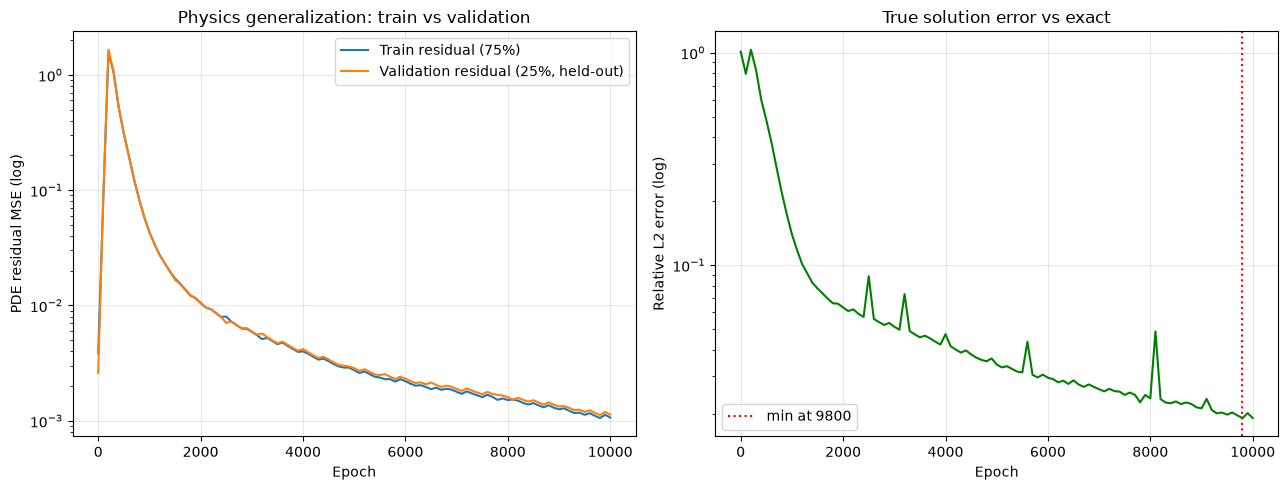

In [10]:
ep = np.array(hist["ep"])
tr = np.array(hist["train_res"]); va = np.array(hist["val_res"]); se = np.array(hist["sol_err"])
best_val = int(ep[va.argmin()]); best_sol = int(ep[se.argmin()])
gap = va[-1] / tr[-1]

print(f"Min validation residual  at epoch {best_val}  ({va.min():.2e})")
print(f"Min true solution error  at epoch {best_sol}  ({se.min():.2e})")
print(f"Final generalization gap (val/train residual) = {gap:.2f}x")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(ep, tr, label="Train residual (75%)")
ax[0].plot(ep, va, label="Validation residual (25%, held-out)")
ax[0].set_yscale("log"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("PDE residual MSE (log)")
ax[0].set_title("Physics generalization: train vs validation"); ax[0].legend(); ax[0].grid(True, alpha=.3)

ax[1].plot(ep, se, color="green")
ax[1].axvline(best_sol, ls=":", color="red", label=f"min at {best_sol}")
ax[1].set_yscale("log"); ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Relative L2 error (log)")
ax[1].set_title("True solution error vs exact"); ax[1].legend(); ax[1].grid(True, alpha=.3)

plt.tight_layout(); plt.show()